In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"

  # IPython 7.14 deprecated set_matplotlib_formats from IPython
  try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
  except ImportError:
    # Fall back to deprecated location for older IPython versions
    from IPython.display import set_matplotlib_formats
    
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'QzpcVXNlcnNcbG9pY2hcRG9jdW1lbnRzXFdvcmtcR2l0aHViXHF1YXJ0b1xweXRob25faWFfcXVhcnRvXG1vZHVsZXNcbW9kdWxlXzA2'
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\importlib\\_bootstrap.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\importlib\\_bootstrap_external.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\zipimport.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\codecs.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\aliases.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\__init__.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\utf_8.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\cp1252.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\abc.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python

In [2]:
#| label: setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_moons, make_classification, make_circles
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier  # pour comparaison
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
np.random.seed(42)

print("✅ Environnement prêt")

✅ Environnement prêt


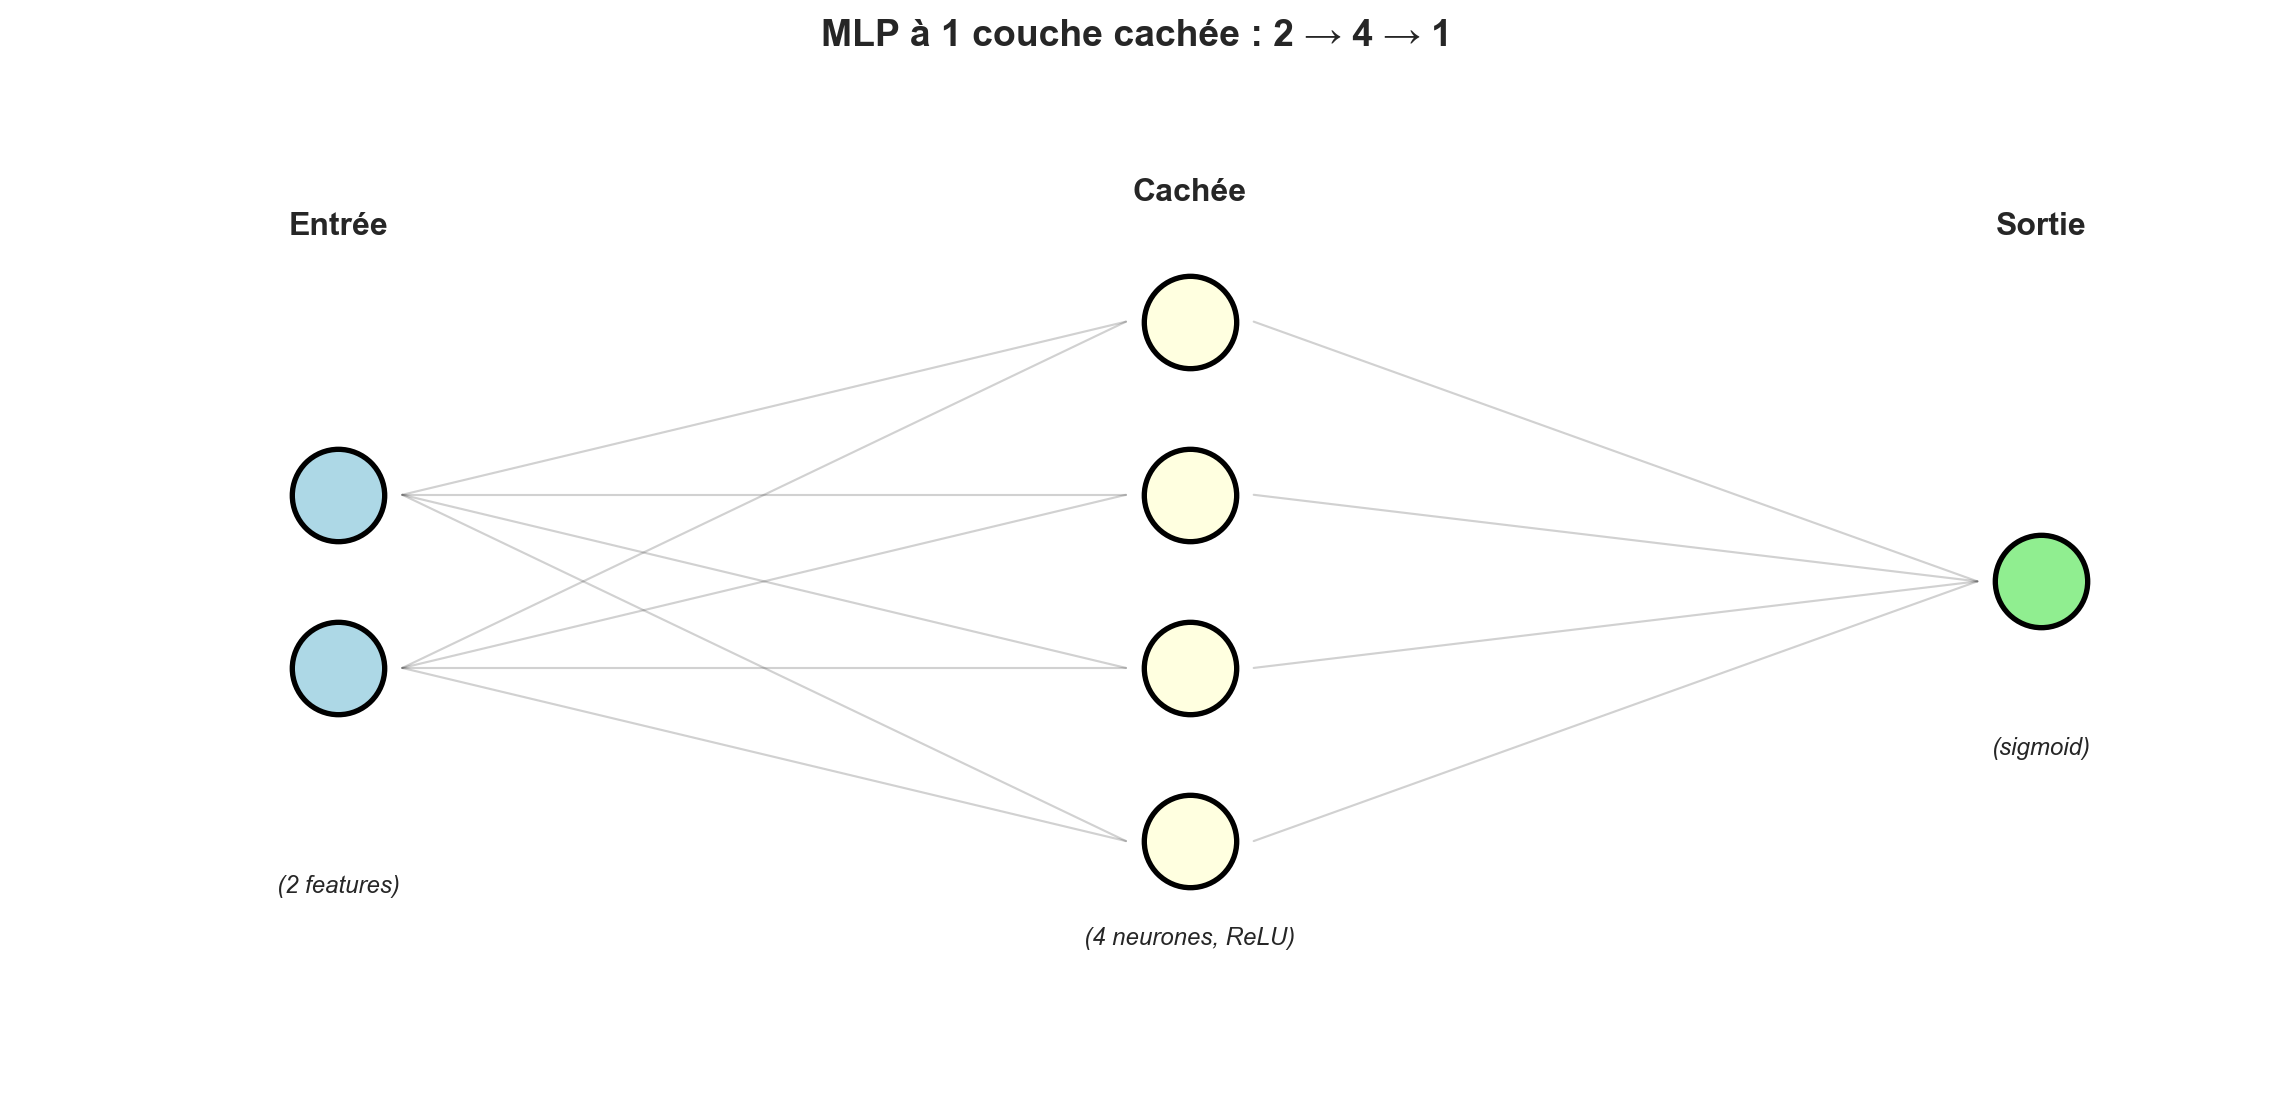

In [3]:
#| label: fig-mlp-arch
#| fig-cap: Architecture d'un MLP à 1 couche cachée

fig, ax = plt.subplots(figsize=(12, 6))
ax.set_xlim(-0.5, 10); ax.set_ylim(-0.5, 5.5)
ax.axis("off")

# Couche d'entrée (2 neurones)
for i, y in enumerate([3, 2]):
    ax.scatter(1, y, s=1200, c="lightblue", edgecolor="black", linewidth=2, zorder=5)
    ax.text(1, y, f"x{i+1}", ha="center", va="center", fontsize=12, fontweight="bold")
ax.text(1, 4.5, "Entrée", ha="center", fontweight="bold", fontsize=12)
ax.text(1, 0.7, "(2 features)", ha="center", fontsize=9, style="italic")

# Couche cachée (4 neurones)
hidden_y = [4, 3, 2, 1]
for y in hidden_y:
    ax.scatter(5, y, s=1200, c="lightyellow", edgecolor="black", linewidth=2, zorder=5)
    ax.text(5, y, "h", ha="center", va="center", fontsize=11, fontweight="bold")
ax.text(5, 4.7, "Cachée", ha="center", fontweight="bold", fontsize=12)
ax.text(5, 0.4, "(4 neurones, ReLU)", ha="center", fontsize=9, style="italic")

# Couche de sortie (1 neurone)
ax.scatter(9, 2.5, s=1200, c="lightgreen", edgecolor="black", linewidth=2, zorder=5)
ax.text(9, 2.5, "ŷ", ha="center", va="center", fontsize=13, fontweight="bold")
ax.text(9, 4.5, "Sortie", ha="center", fontweight="bold", fontsize=12)
ax.text(9, 1.5, "(sigmoid)", ha="center", fontsize=9, style="italic")

# Connexions entrée -> cachée
for y1 in [3, 2]:
    for y2 in hidden_y:
        ax.plot([1.3, 4.7], [y1, y2], "k-", alpha=0.2, linewidth=0.8)

# Connexions cachée -> sortie
for y1 in hidden_y:
    ax.plot([5.3, 8.7], [y1, 2.5], "k-", alpha=0.2, linewidth=0.8)

ax.set_title("MLP à 1 couche cachée : 2 → 4 → 1", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [4]:
# Données XOR
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
y_xor = np.array([0, 1, 1, 0])

print("Données XOR :")
for x, y in zip(X_xor, y_xor):
    print(f"  {x} → {y}")

Données XOR :
  [0. 0.] → 0
  [0. 1.] → 1
  [1. 0.] → 1
  [1. 1.] → 0


In [5]:
# MLP : 2 entrées → 3 neurones cachés (tanh) → 1 sortie
mlp = MLPClassifier(
    hidden_layer_sizes=(3,),     # 1 couche cachée de 3 neurones
    activation="tanh",
    solver="lbfgs",              # bon pour petits datasets
    max_iter=2000,
    random_state=42
)
mlp.fit(X_xor, y_xor)

# Prédictions
pred = mlp.predict(X_xor)
print(f"\nPrédictions : {pred}")
print(f"Vraies valeurs : {y_xor}")
print(f"Accuracy : {(pred == y_xor).mean():.2%}")


Prédictions : [0 1 1 0]
Vraies valeurs : [0 1 1 0]
Accuracy : 100.00%


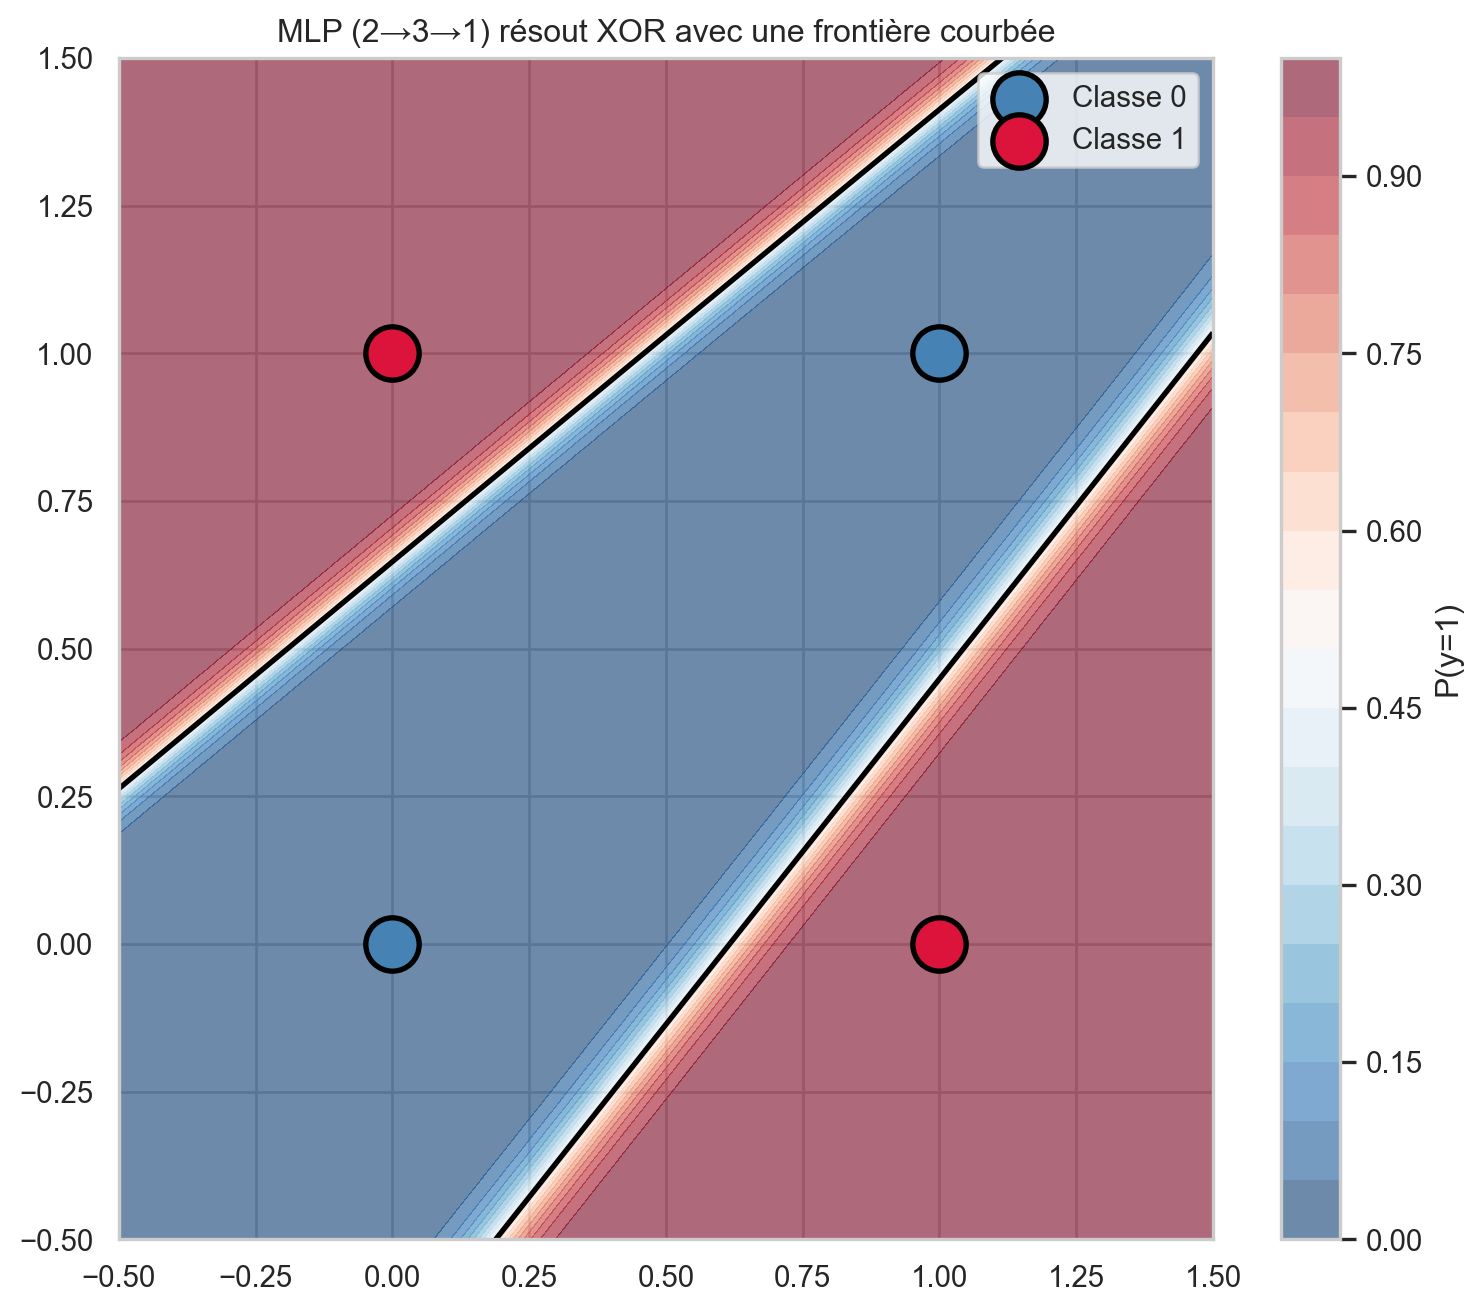

In [6]:
#| label: fig-xor-solved
#| fig-cap: Un MLP résout XOR — frontière non-linéaire

# Grille pour visualiser
xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200), np.linspace(-0.5, 1.5, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = mlp.predict_proba(grid)[:, 1].reshape(xx.shape)

fig, ax = plt.subplots(figsize=(8, 7))
contour = ax.contourf(xx, yy, Z, levels=20, cmap="RdBu_r", alpha=0.6)
plt.colorbar(contour, label="P(y=1)")

# Contour de décision (P=0.5)
ax.contour(xx, yy, Z, levels=[0.5], colors="black", linewidths=2)

# Points
ax.scatter(X_xor[y_xor == 0, 0], X_xor[y_xor == 0, 1], s=400, c="steelblue",
           edgecolor="black", linewidth=2, label="Classe 0", zorder=5)
ax.scatter(X_xor[y_xor == 1, 0], X_xor[y_xor == 1, 1], s=400, c="crimson",
           edgecolor="black", linewidth=2, label="Classe 1", zorder=5)

ax.set_title("MLP (2→3→1) résout XOR avec une frontière courbée")
ax.legend()
plt.tight_layout()
plt.show()

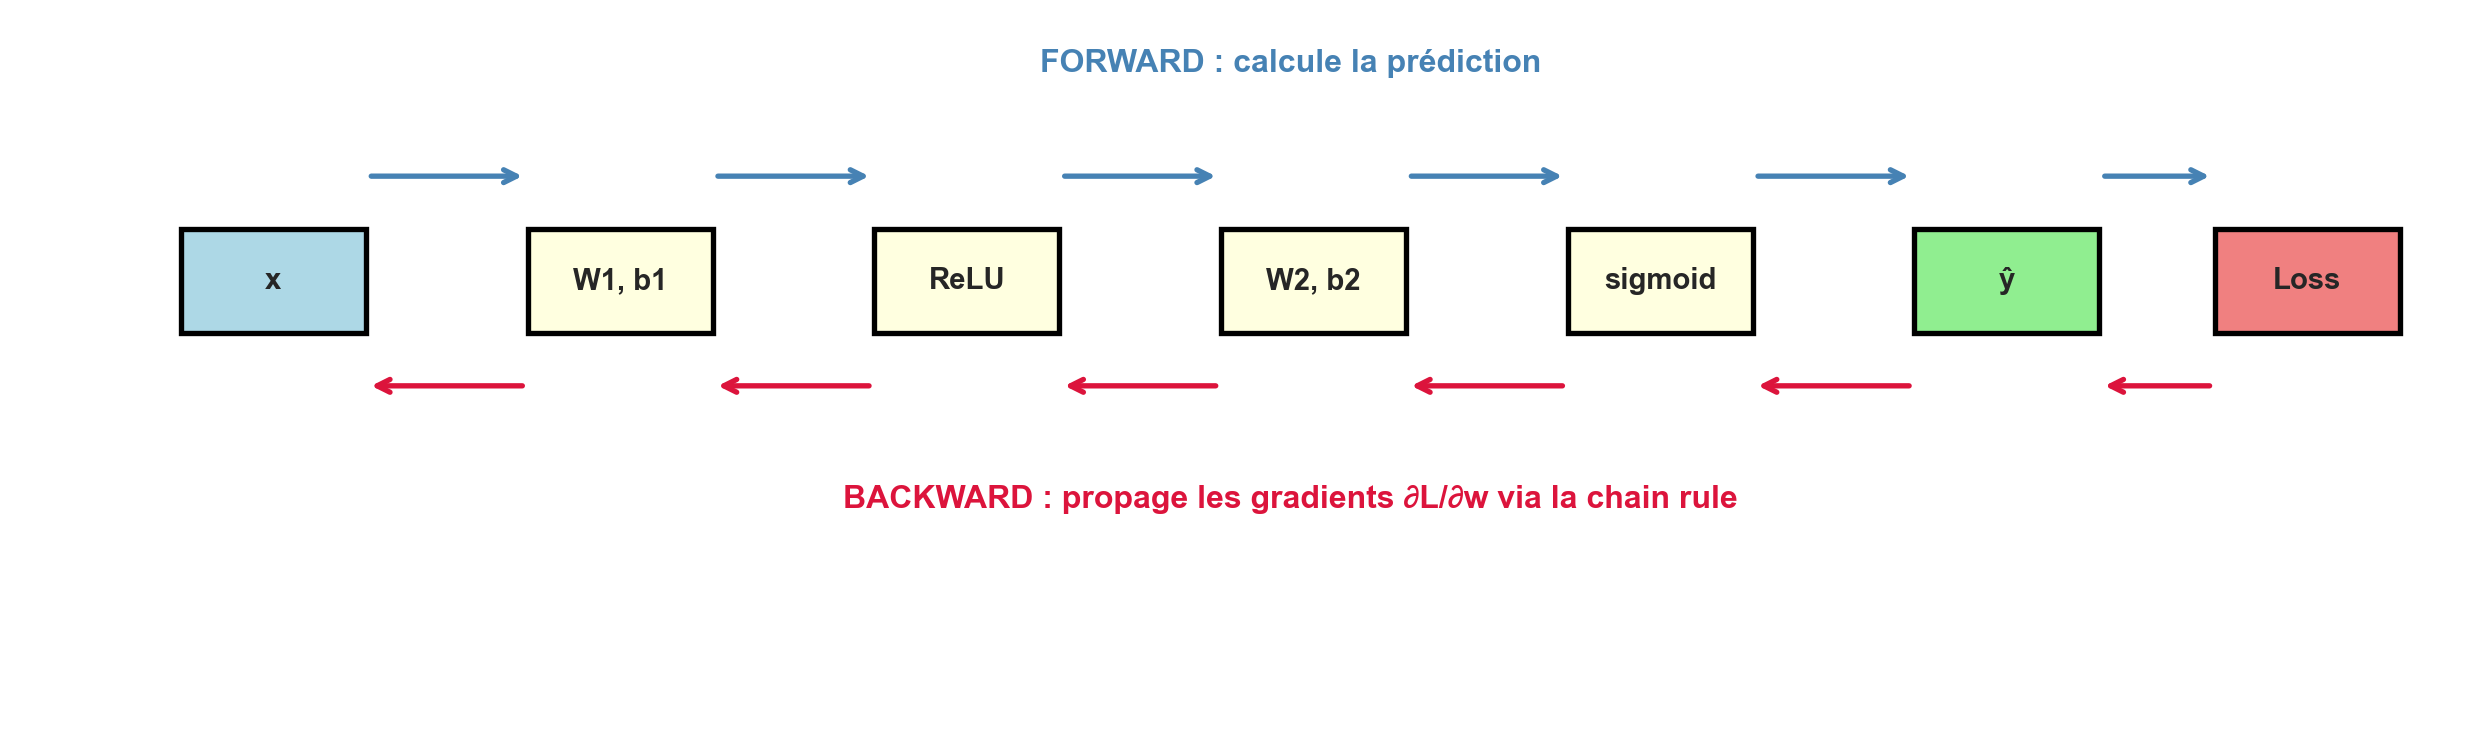

In [7]:
#| label: fig-backprop
#| fig-cap: Forward (bleu) vs Backward (rouge)

fig, ax = plt.subplots(figsize=(13, 4))
ax.set_xlim(-0.5, 10); ax.set_ylim(-1, 3)
ax.axis("off")

# Boîtes
boxes = [
    (0.5, 1.5, "x"),
    (2, 1.5, "W1, b1"),
    (3.5, 1.5, "ReLU"),
    (5, 1.5, "W2, b2"),
    (6.5, 1.5, "sigmoid"),
    (8, 1.5, "ŷ"),
    (9.3, 1.5, "Loss"),
]
for x, y, label in boxes:
    color = "lightyellow" if "," in label or label in ["ReLU", "sigmoid"] else "lightblue"
    if label == "Loss":
        color = "lightcoral"
    elif label == "ŷ":
        color = "lightgreen"
    ax.add_patch(plt.Rectangle((x - 0.3, y - 0.3), 0.8, 0.6,
                                 facecolor=color, edgecolor="black", linewidth=2))
    ax.text(x + 0.1, y, label, ha="center", va="center", fontsize=11, fontweight="bold")

# Flèches FORWARD (bleues, en haut)
for i in range(len(boxes) - 1):
    x1 = boxes[i][0] + 0.5
    x2 = boxes[i + 1][0] - 0.3
    ax.annotate("", xy=(x2, 2.1), xytext=(x1, 2.1),
                 arrowprops=dict(arrowstyle="->", color="steelblue", lw=2))
ax.text(5, 2.7, "FORWARD : calcule la prédiction", ha="center",
        color="steelblue", fontsize=12, fontweight="bold")

# Flèches BACKWARD (rouges, en bas)
for i in range(len(boxes) - 1, 0, -1):
    x1 = boxes[i][0] - 0.3
    x2 = boxes[i - 1][0] + 0.5
    ax.annotate("", xy=(x2, 0.9), xytext=(x1, 0.9),
                 arrowprops=dict(arrowstyle="->", color="crimson", lw=2))
ax.text(5, 0.2, "BACKWARD : propage les gradients ∂L/∂w via la chain rule",
        ha="center", color="crimson", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

In [8]:
# Fonctions utiles
def relu(x):
    return np.maximum(0, x)

def relu_deriv(x):
    return (x > 0).astype(float)

def sigmoid(x):
    # Version stable numériquement
    return np.where(x >= 0, 1 / (1 + np.exp(-x)), np.exp(x) / (1 + np.exp(x)))

def binary_cross_entropy(y_true, y_pred):
    eps = 1e-12  # évite log(0)
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

In [9]:
class MLP:
    """MLP à 1 couche cachée, pour classification binaire."""
    
    def __init__(self, n_input, n_hidden, seed=42):
        rng = np.random.default_rng(seed)
        # Initialisation "Xavier" : petits poids, mais pas nuls
        self.W1 = rng.normal(0, np.sqrt(2 / n_input), (n_input, n_hidden))
        self.b1 = np.zeros(n_hidden)
        self.W2 = rng.normal(0, np.sqrt(2 / n_hidden), (n_hidden, 1))
        self.b2 = np.zeros(1)
    
    def forward(self, X):
        """Propagation avant. Stocke les valeurs pour la backprop."""
        self.X = X
        self.z1 = X @ self.W1 + self.b1
        self.a1 = relu(self.z1)
        self.z2 = self.a1 @ self.W2 + self.b2
        self.y_pred = sigmoid(self.z2).ravel()
        return self.y_pred
    
    def backward(self, y_true, lr=0.1):
        """Rétropropagation + mise à jour."""
        n = len(y_true)
        
        # Gradient de la sortie (sigmoid + BCE donne une formule simple)
        dz2 = (self.y_pred - y_true).reshape(-1, 1) / n
        
        # Gradients couche de sortie
        dW2 = self.a1.T @ dz2
        db2 = dz2.sum(axis=0)
        
        # Remonter à la couche cachée
        da1 = dz2 @ self.W2.T
        dz1 = da1 * relu_deriv(self.z1)
        
        # Gradients couche cachée
        dW1 = self.X.T @ dz1
        db1 = dz1.sum(axis=0)
        
        # Mise à jour (descente de gradient)
        self.W1 -= lr * dW1
        self.b1 -= lr * db1
        self.W2 -= lr * dW2
        self.b2 -= lr * db2
    
    def fit(self, X, y, lr=0.1, n_epochs=1000, verbose=False):
        """Entraînement complet."""
        self.losses = []
        for epoch in range(n_epochs):
            y_pred = self.forward(X)
            loss = binary_cross_entropy(y, y_pred)
            self.losses.append(loss)
            self.backward(y, lr=lr)
            if verbose and (epoch + 1) % 100 == 0:
                print(f"Époque {epoch + 1} : loss = {loss:.4f}")
    
    def predict(self, X):
        return (self.forward(X) >= 0.5).astype(int)

In [10]:
# Entraîner sur XOR
mlp = MLP(n_input=2, n_hidden=4, seed=0)
mlp.fit(X_xor, y_xor, lr=0.5, n_epochs=2000, verbose=True)

pred = mlp.predict(X_xor)
print(f"\nPrédictions : {pred}")
print(f"Vérité      : {y_xor}")
print(f"Accuracy    : {(pred == y_xor).mean():.2%}")

Époque 100 : loss = 0.2103
Époque 200 : loss = 0.0519
Époque 300 : loss = 0.0255
Époque 400 : loss = 0.0164
Époque 500 : loss = 0.0118
Époque 600 : loss = 0.0092
Époque 700 : loss = 0.0075
Époque 800 : loss = 0.0063
Époque 900 : loss = 0.0054
Époque 1000 : loss = 0.0047
Époque 1100 : loss = 0.0042
Époque 1200 : loss = 0.0038
Époque 1300 : loss = 0.0034
Époque 1400 : loss = 0.0031
Époque 1500 : loss = 0.0029
Époque 1600 : loss = 0.0027
Époque 1700 : loss = 0.0025
Époque 1800 : loss = 0.0023
Époque 1900 : loss = 0.0022
Époque 2000 : loss = 0.0020

Prédictions : [0 1 1 0]
Vérité      : [0 1 1 0]
Accuracy    : 100.00%


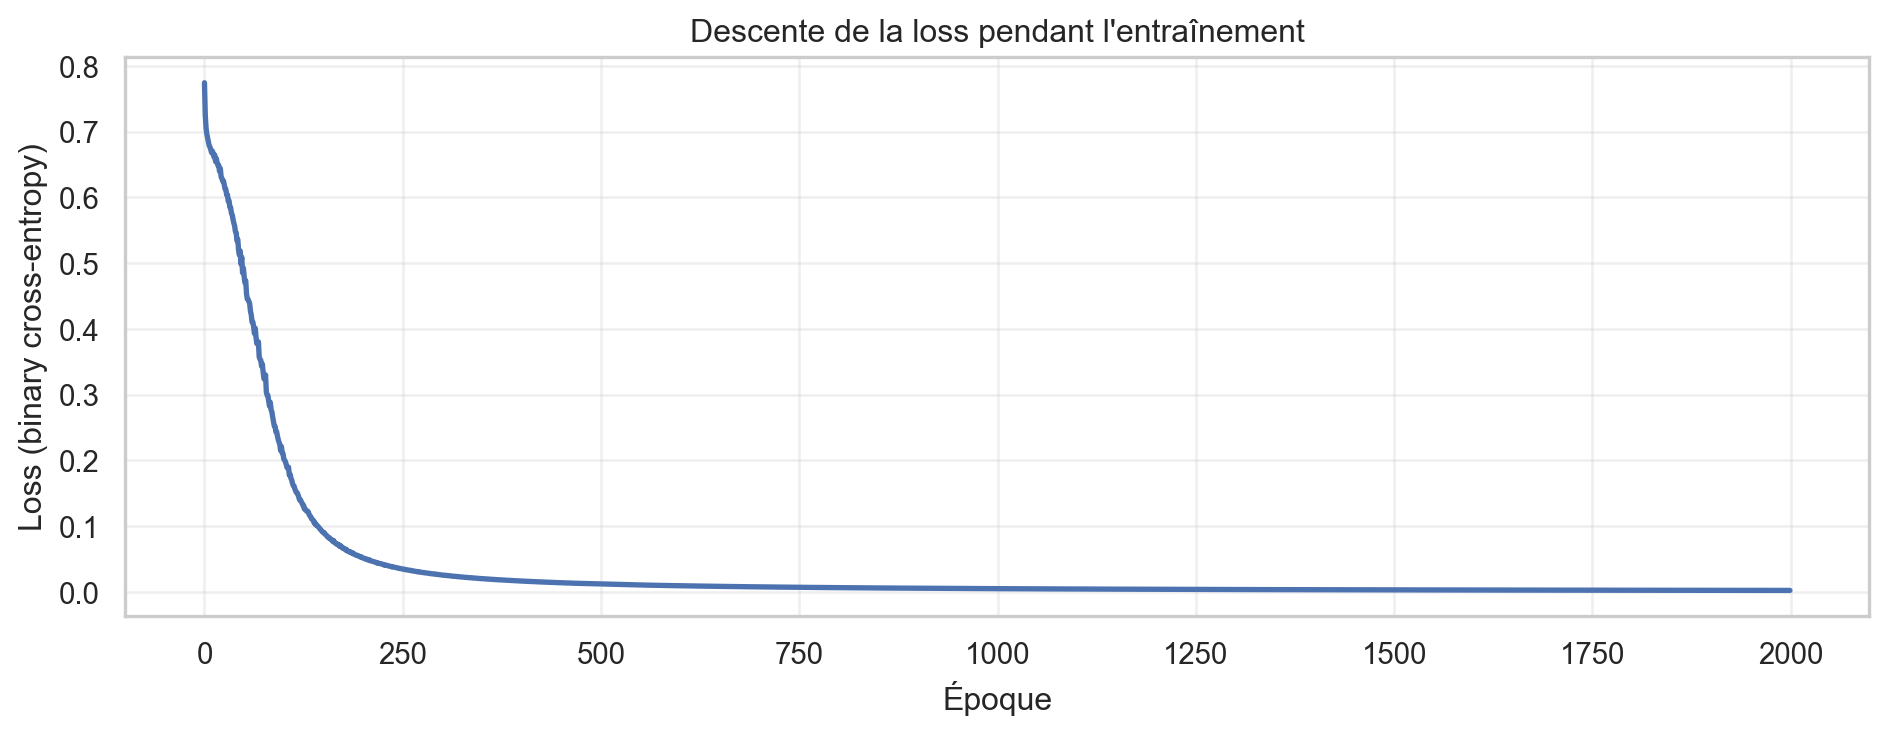

In [11]:
#| label: fig-loss-curve
#| fig-cap: Courbe d'apprentissage du MLP sur XOR

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(mlp.losses, linewidth=2)
ax.set_xlabel("Époque")
ax.set_ylabel("Loss (binary cross-entropy)")
ax.set_title("Descente de la loss pendant l'entraînement")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

C:\Users\loich\AppData\Local\Temp\ipykernel_39580\3180024202.py:16: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\loich\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


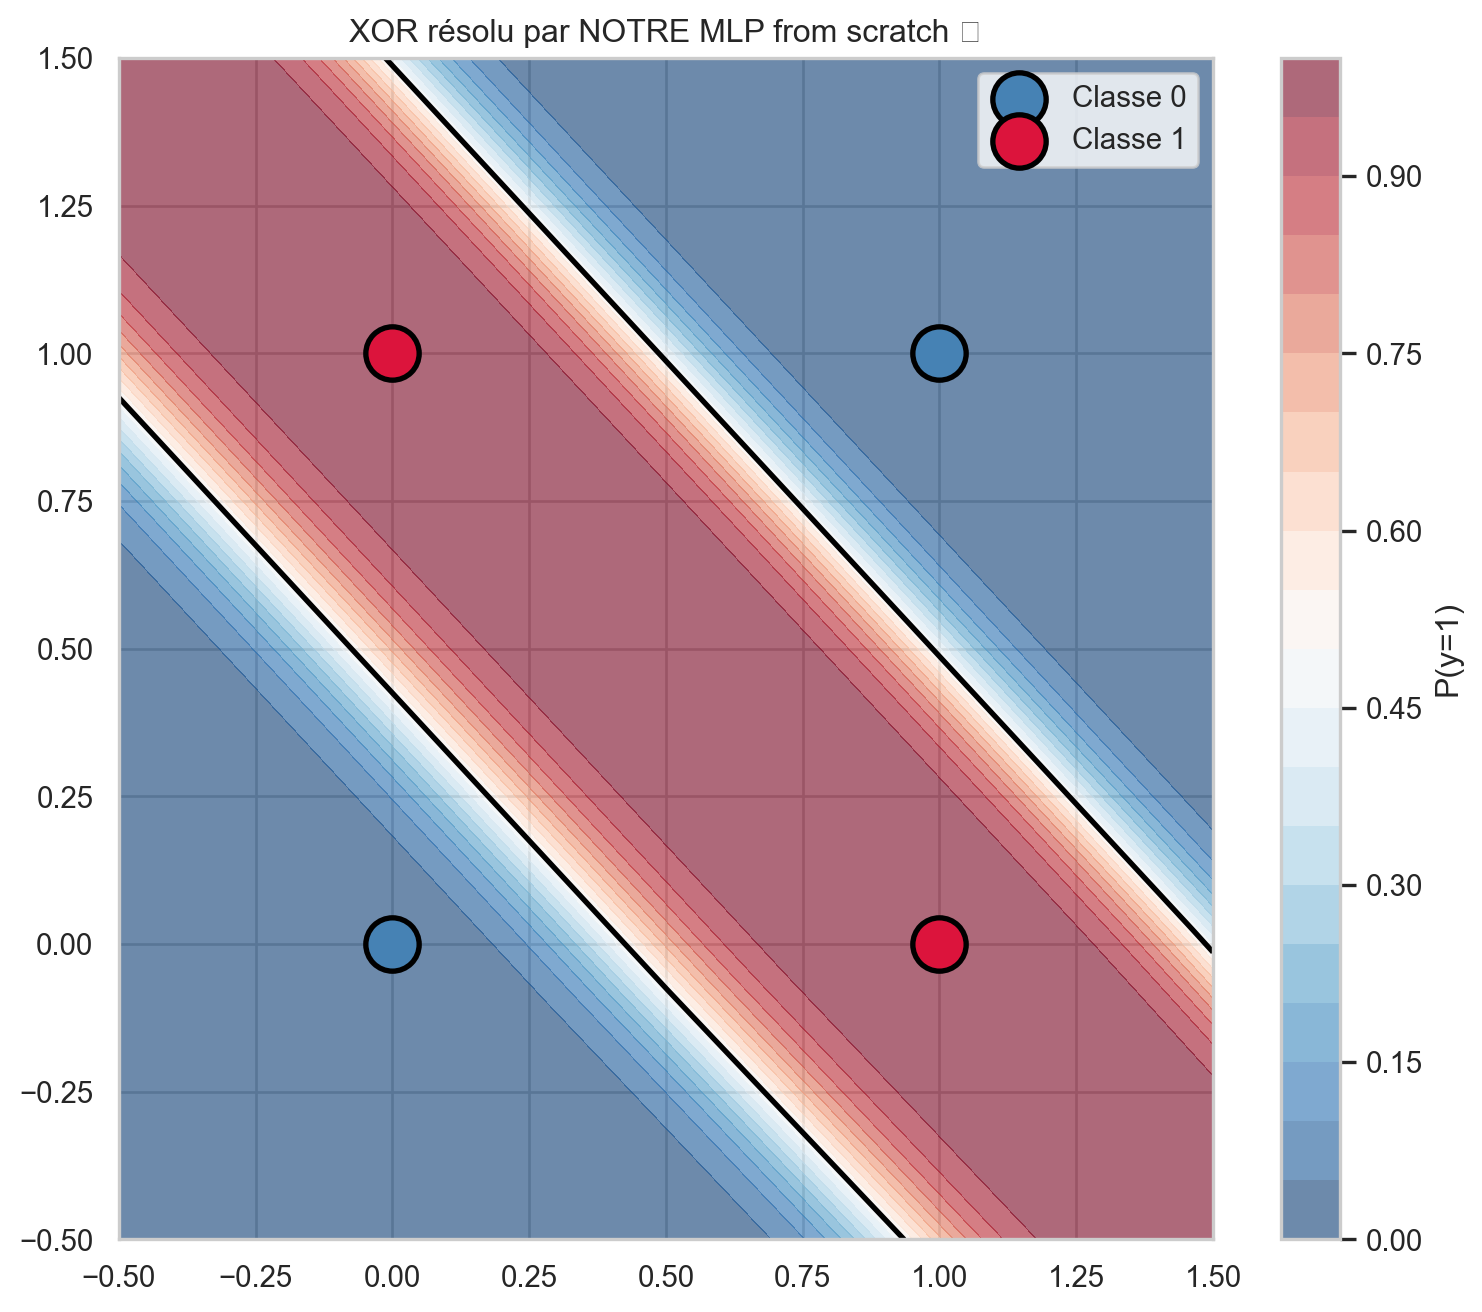

In [12]:
#| label: fig-xor-from-scratch
#| fig-cap: Frontière apprise par notre MLP from scratch

xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200), np.linspace(-0.5, 1.5, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = mlp.forward(grid).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(8, 7))
contour = ax.contourf(xx, yy, Z, levels=20, cmap="RdBu_r", alpha=0.6)
plt.colorbar(contour, label="P(y=1)")
ax.contour(xx, yy, Z, levels=[0.5], colors="black", linewidths=2)

ax.scatter(X_xor[y_xor == 0, 0], X_xor[y_xor == 0, 1], s=400, c="steelblue",
           edgecolor="black", linewidth=2, label="Classe 0", zorder=5)
ax.scatter(X_xor[y_xor == 1, 0], X_xor[y_xor == 1, 1], s=400, c="crimson",
           edgecolor="black", linewidth=2, label="Classe 1", zorder=5)
ax.set_title("XOR résolu par NOTRE MLP from scratch ✨")
ax.legend()
plt.tight_layout()
plt.show()

In [13]:
#| eval: false
# TODO: Exercice 1

Accuracy : 0.998


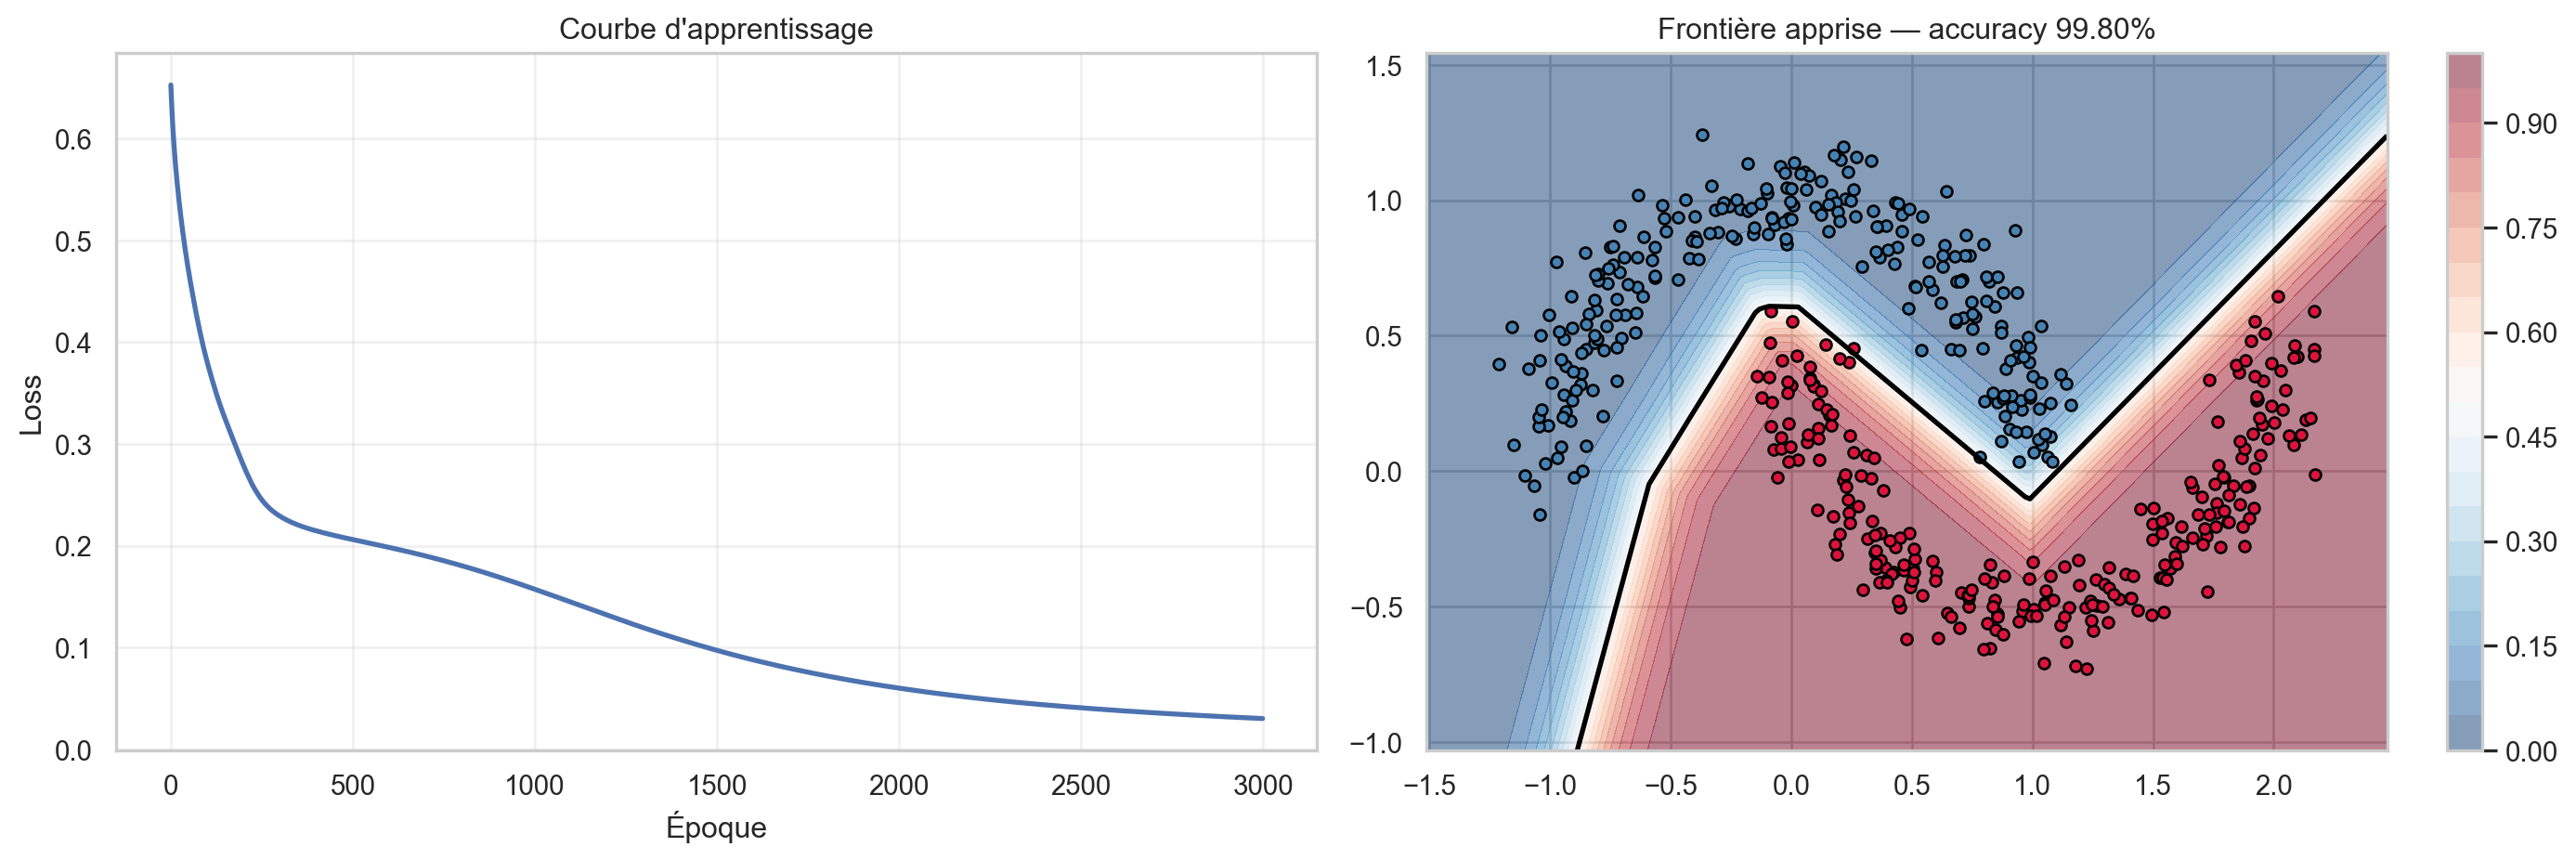

In [14]:
X, y = make_moons(n_samples=500, noise=0.1, random_state=42)

mlp_moons = MLP(n_input=2, n_hidden=8, seed=42)
mlp_moons.fit(X, y, lr=0.1, n_epochs=3000)

pred = mlp_moons.predict(X)
acc = (pred == y).mean()
print(f"Accuracy : {acc:.3f}")

# Figures
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss
axes[0].plot(mlp_moons.losses, linewidth=2)
axes[0].set_xlabel("Époque"); axes[0].set_ylabel("Loss")
axes[0].set_title("Courbe d'apprentissage")
axes[0].grid(True, alpha=0.3)

# Frontière
xx, yy = np.meshgrid(
    np.linspace(X[:, 0].min() - 0.3, X[:, 0].max() + 0.3, 200),
    np.linspace(X[:, 1].min() - 0.3, X[:, 1].max() + 0.3, 200)
)
grid = np.c_[xx.ravel(), yy.ravel()]
Z = mlp_moons.forward(grid).reshape(xx.shape)
contour = axes[1].contourf(xx, yy, Z, levels=20, cmap="RdBu_r", alpha=0.5)
axes[1].contour(xx, yy, Z, levels=[0.5], colors="black", linewidths=2)
axes[1].scatter(X[y == 0, 0], X[y == 0, 1], s=20, c="steelblue", edgecolor="black")
axes[1].scatter(X[y == 1, 0], X[y == 1, 1], s=20, c="crimson", edgecolor="black")
axes[1].set_title(f"Frontière apprise — accuracy {acc:.2%}")
plt.colorbar(contour, ax=axes[1])

plt.tight_layout()
plt.show()

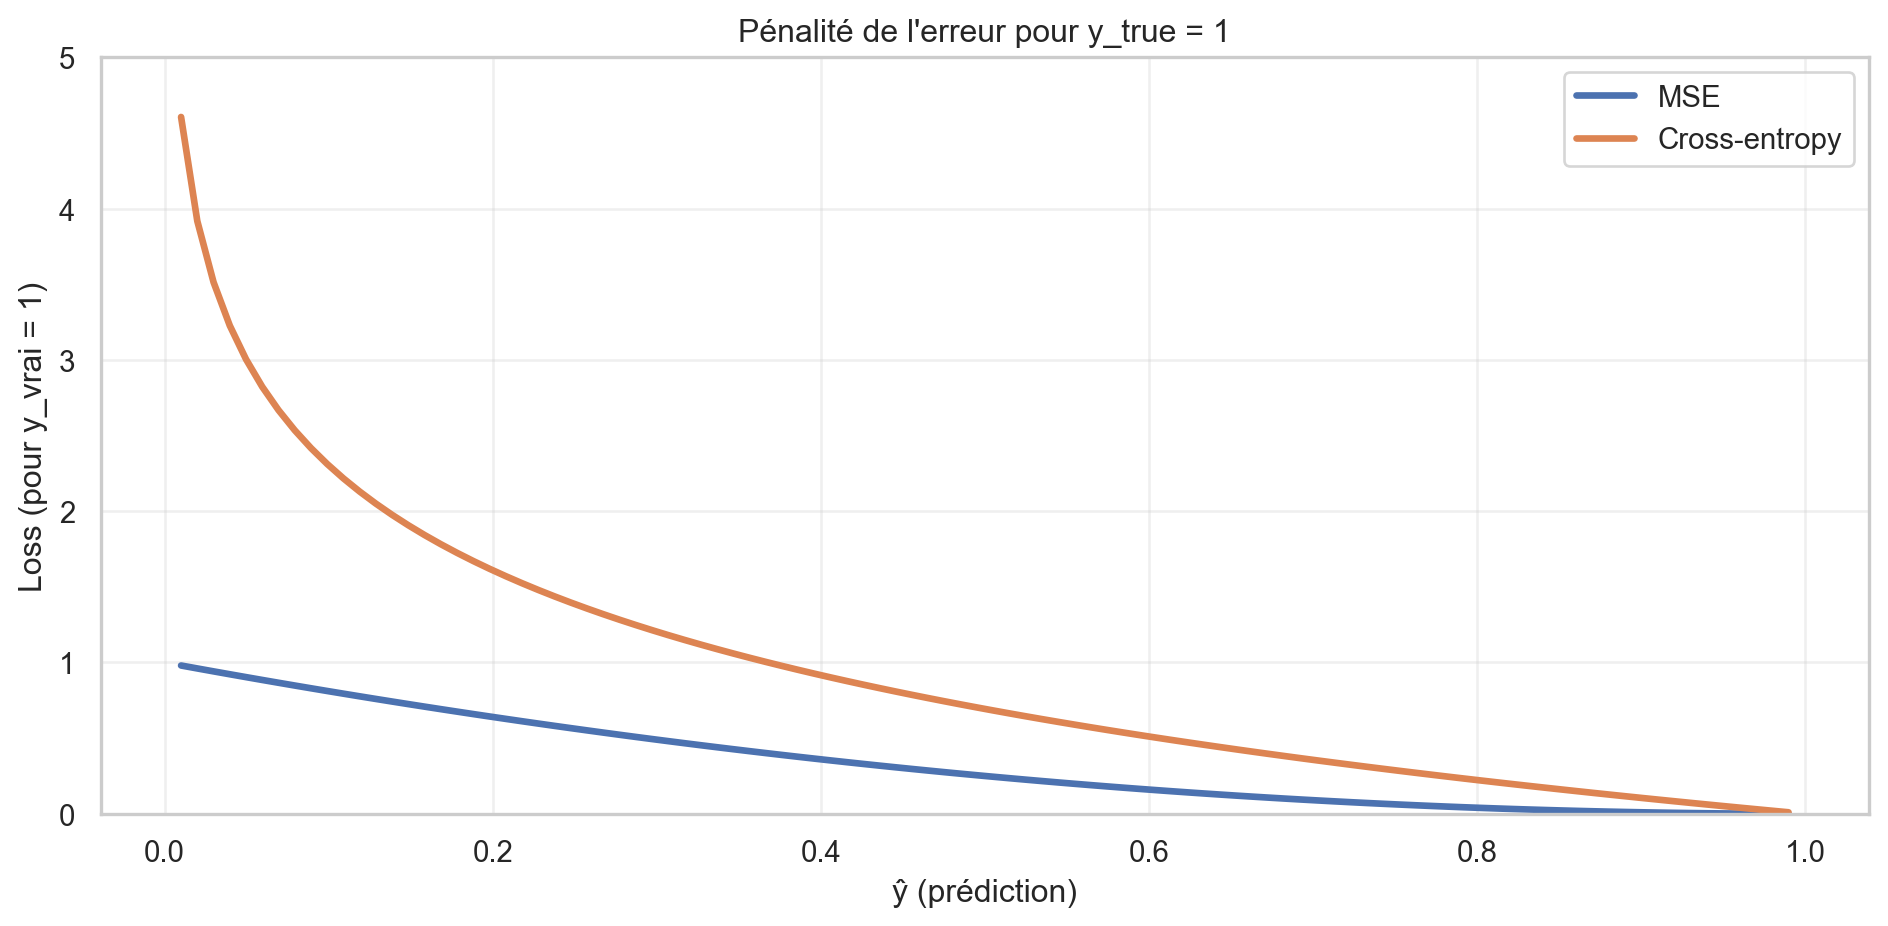

In [15]:
#| label: fig-loss-comparison
#| fig-cap: 'MSE vs Cross-entropy : comportement différent sur la classification'

y_pred = np.linspace(0.01, 0.99, 100)

# Pour y_true = 1
mse = (1 - y_pred) ** 2
bce = -np.log(y_pred)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(y_pred, mse, linewidth=2.5, label="MSE")
ax.plot(y_pred, bce, linewidth=2.5, label="Cross-entropy")
ax.set_xlabel("ŷ (prédiction)")
ax.set_ylabel("Loss (pour y_vrai = 1)")
ax.set_title("Pénalité de l'erreur pour y_true = 1")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 5)
plt.tight_layout()
plt.show()

In [16]:
def softmax(z):
    """Version stable numériquement (soustraction du max)."""
    exp_z = np.exp(z - np.max(z, axis=-1, keepdims=True))
    return exp_z / exp_z.sum(axis=-1, keepdims=True)

# Exemple
scores = np.array([2.0, 1.0, 0.1])
probas = softmax(scores)
print(f"Scores bruts     : {scores}")
print(f"Après softmax    : {probas.round(3)}")
print(f"Somme            : {probas.sum():.3f}")

Scores bruts     : [2.  1.  0.1]
Après softmax    : [0.659 0.242 0.099]
Somme            : 1.000


In [17]:
from sklearn.datasets import load_iris

iris = load_iris()
X, y = iris.data, iris.target
X = StandardScaler().fit_transform(X)

# sklearn pour aller vite
mlp_iris = MLPClassifier(
    hidden_layer_sizes=(10,),
    activation="relu",
    solver="adam",
    max_iter=500,
    random_state=42
)
mlp_iris.fit(X, y)

acc = mlp_iris.score(X, y)
print(f"Accuracy Iris : {acc:.3f}")
print(f"\nProbas du 1er exemple (softmax en interne) :")
print(f"  {mlp_iris.predict_proba(X[:1])[0].round(3)}")
print(f"  → Classe prédite : {mlp_iris.predict(X[:1])[0]} (vraie = {y[0]})")

Accuracy Iris : 0.967

Probas du 1er exemple (softmax en interne) :
  [0.987 0.007 0.006]
  → Classe prédite : 0 (vraie = 0)


C:\Users\loich\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [18]:
#| eval: false
# TODO: Exercice 2

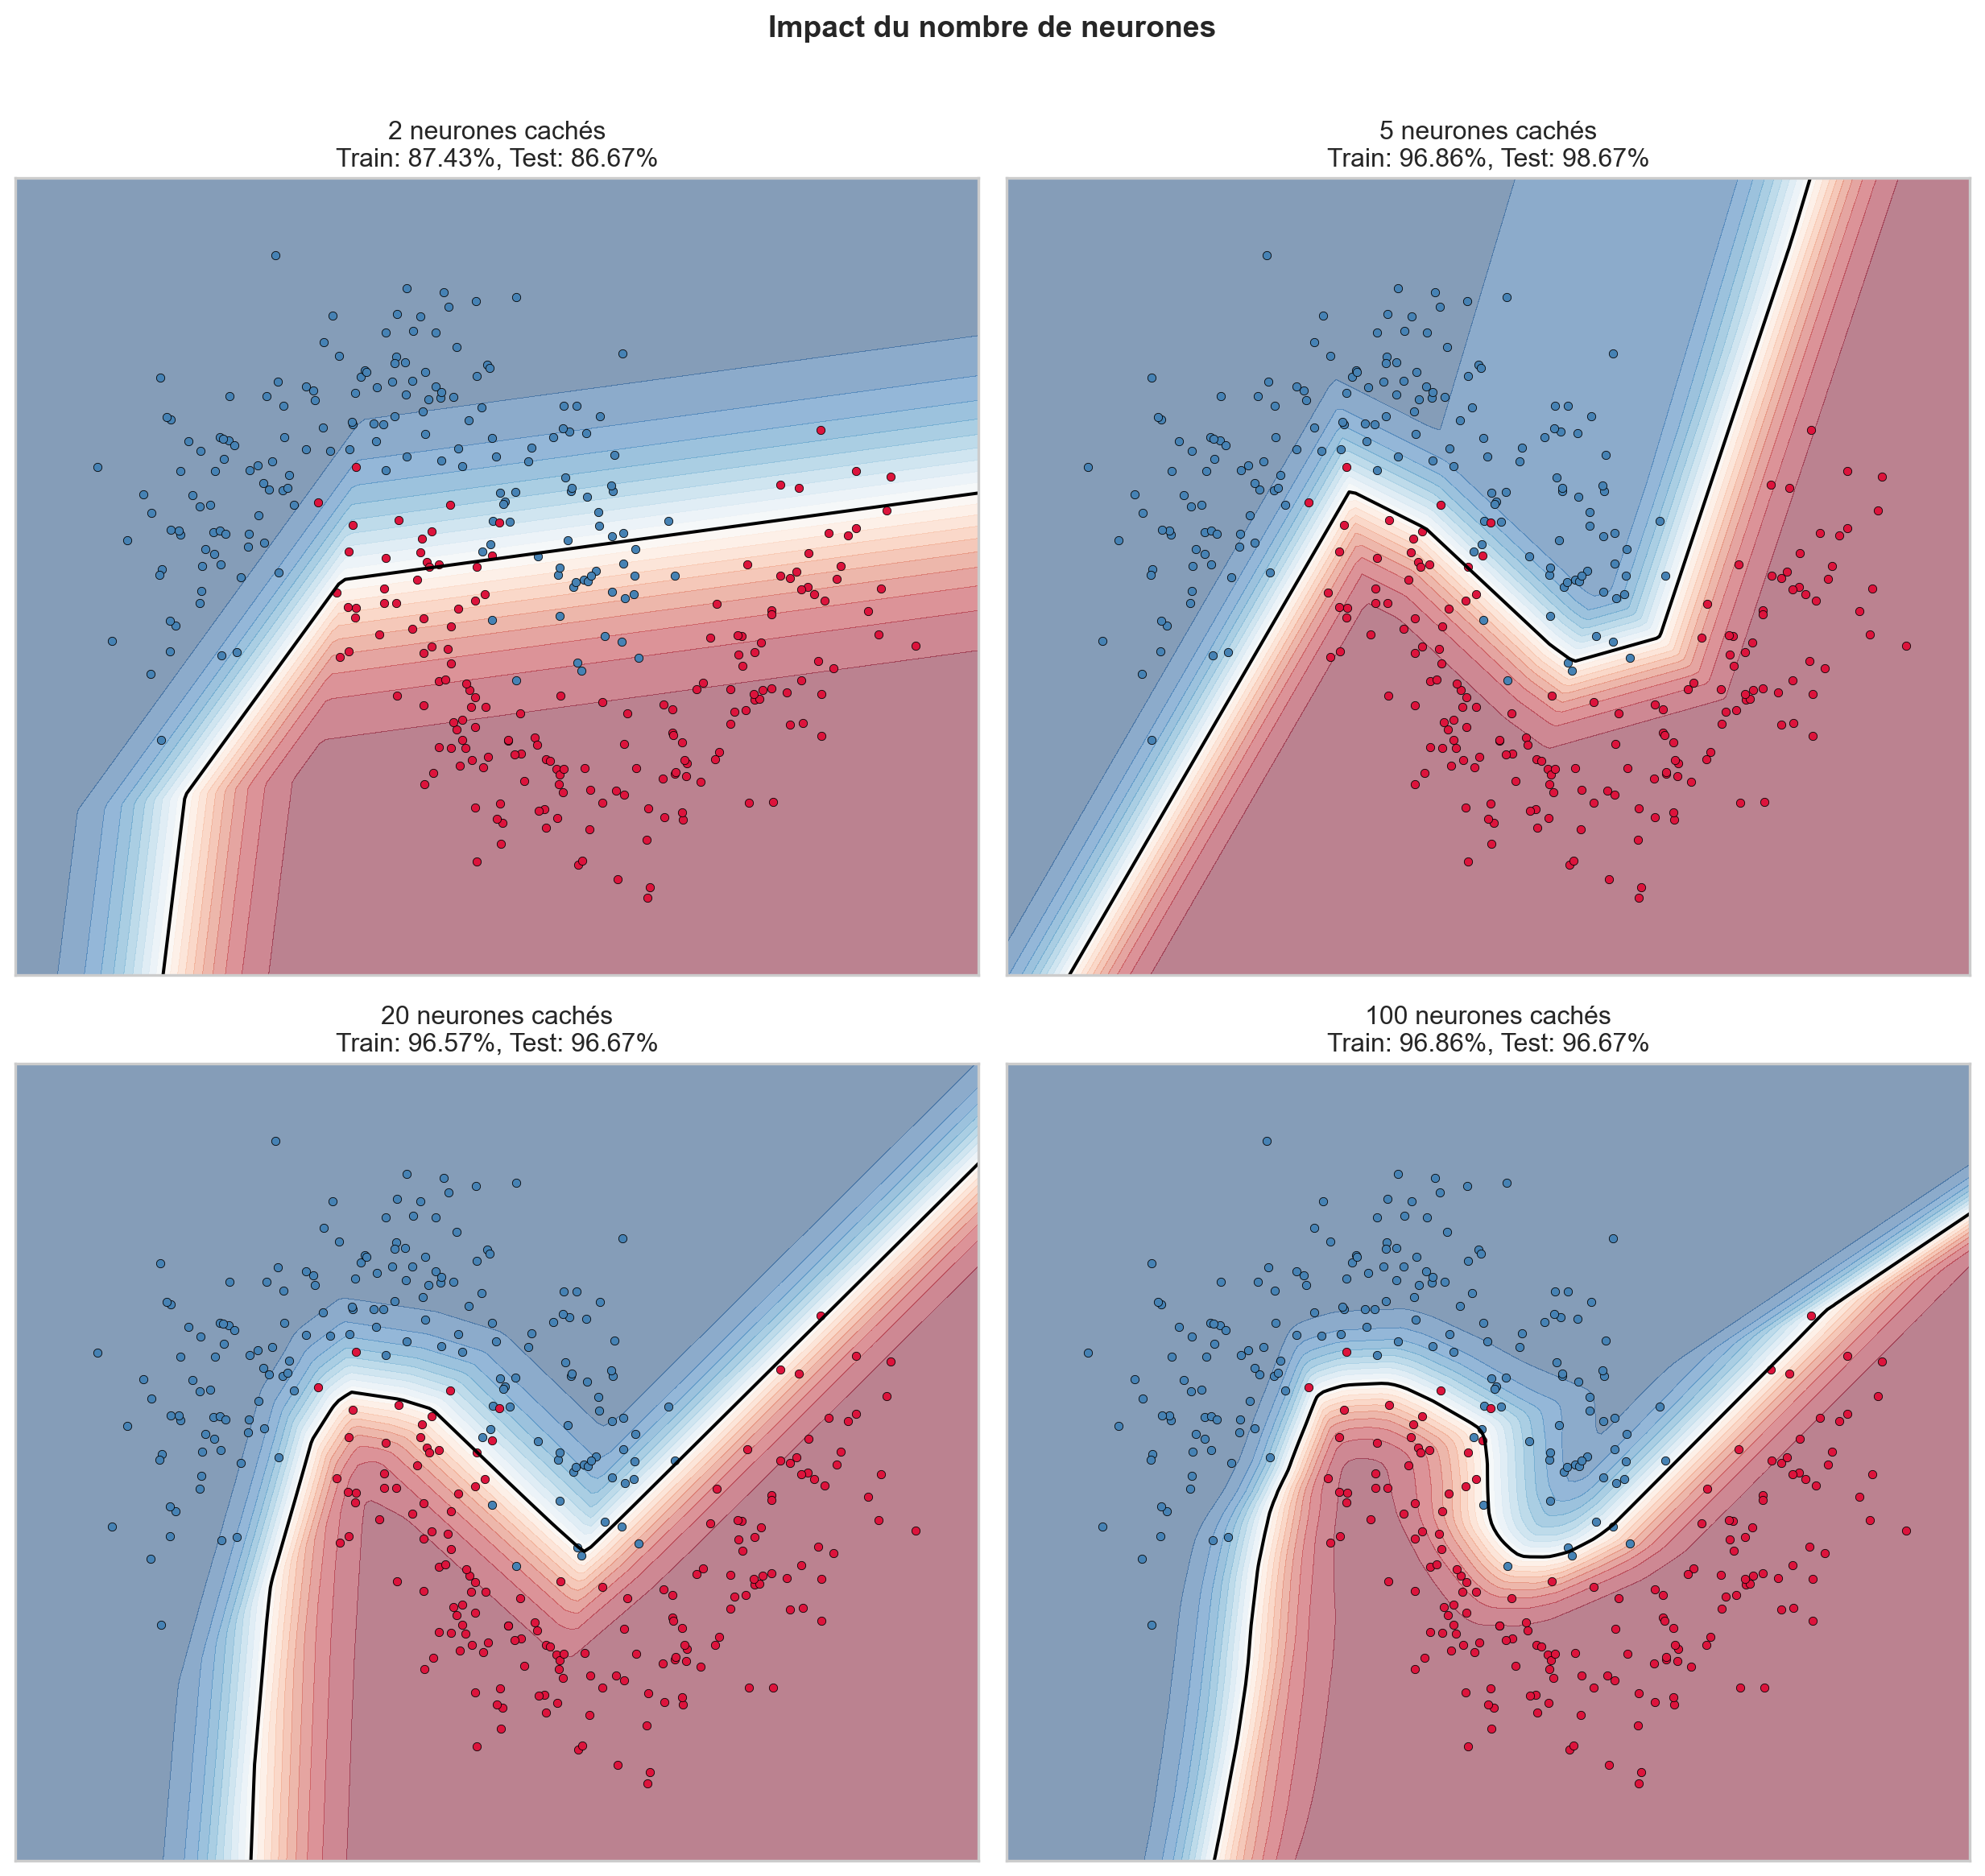

In [19]:
X, y = make_moons(n_samples=500, noise=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

fig, axes = plt.subplots(2, 2, figsize=(13, 12))

for ax, n_h in zip(axes.flat, [2, 5, 20, 100]):
    mlp_test = MLP(n_input=2, n_hidden=n_h, seed=42)
    mlp_test.fit(X_train, y_train, lr=0.1, n_epochs=2000)
    
    acc_train = (mlp_test.predict(X_train) == y_train).mean()
    acc_test = (mlp_test.predict(X_test) == y_test).mean()
    
    # Visualisation
    xx, yy = np.meshgrid(
        np.linspace(X[:, 0].min() - 0.3, X[:, 0].max() + 0.3, 150),
        np.linspace(X[:, 1].min() - 0.3, X[:, 1].max() + 0.3, 150)
    )
    Z = mlp_test.forward(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=20, cmap="RdBu_r", alpha=0.5)
    ax.contour(xx, yy, Z, levels=[0.5], colors="black", linewidths=1.5)
    ax.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], s=15, 
               c="steelblue", edgecolor="black", linewidth=0.3)
    ax.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], s=15,
               c="crimson", edgecolor="black", linewidth=0.3)
    ax.set_title(f"{n_h} neurones cachés\nTrain: {acc_train:.2%}, Test: {acc_test:.2%}")
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle("Impact du nombre de neurones", fontweight="bold", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [20]:
# Dataset
X, y = make_moons(n_samples=500, noise=0.1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Notre MLP
notre_mlp = MLP(n_input=2, n_hidden=8, seed=42)
notre_mlp.fit(X_train, y_train, lr=0.1, n_epochs=3000)
acc_nous = (notre_mlp.predict(X_test) == y_test).mean()

# MLP sklearn
sk_mlp = MLPClassifier(hidden_layer_sizes=(8,), activation="relu",
                        max_iter=3000, random_state=42, learning_rate_init=0.1)
sk_mlp.fit(X_train, y_train)
acc_sk = sk_mlp.score(X_test, y_test)

print(f"Accuracy test :")
print(f"  Notre MLP   : {acc_nous:.3f}")
print(f"  sklearn MLP : {acc_sk:.3f}")

Accuracy test :
  Notre MLP   : 1.000
  sklearn MLP : 0.900


C:\Users\loich\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\loich\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


MLP (16,)      : train 0.967, test 0.933
MLP (16, 8)    : train 0.975, test 0.967


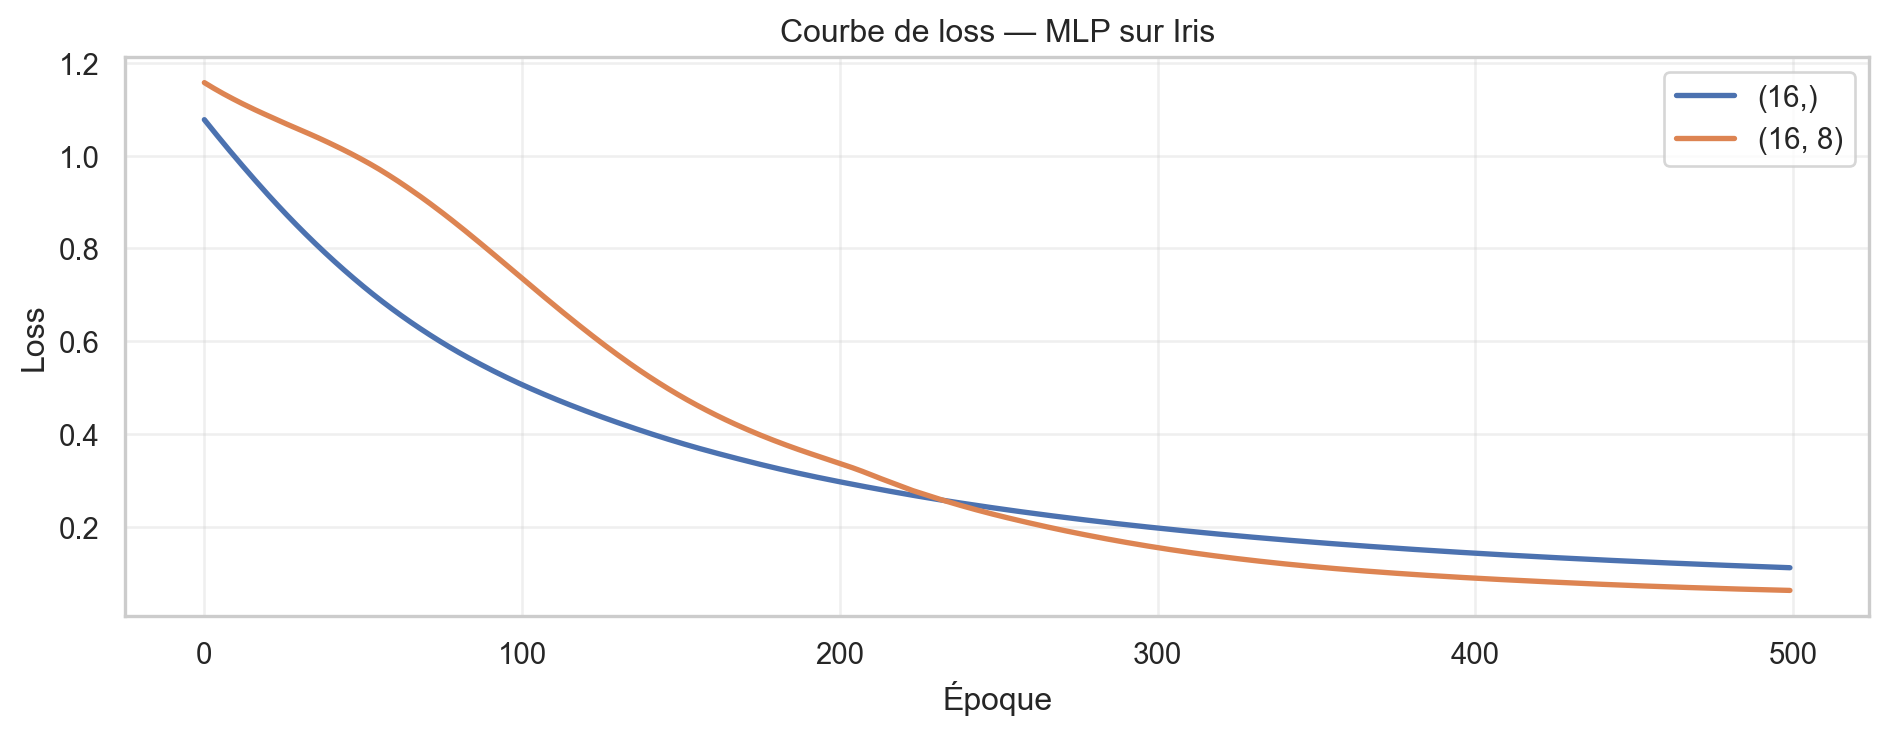

In [21]:
from sklearn.datasets import load_iris

iris = load_iris()
X, y = iris.data, iris.target

# Split + scaling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# MLP à 1 couche cachée
mlp1 = MLPClassifier(hidden_layer_sizes=(16,), activation="relu",
                      solver="adam", max_iter=500, random_state=42)
mlp1.fit(X_train_sc, y_train)

# MLP à 2 couches
mlp2 = MLPClassifier(hidden_layer_sizes=(16, 8), activation="relu",
                      solver="adam", max_iter=500, random_state=42)
mlp2.fit(X_train_sc, y_train)

# Affichage
print(f"MLP (16,)      : train {mlp1.score(X_train_sc, y_train):.3f}, test {mlp1.score(X_test_sc, y_test):.3f}")
print(f"MLP (16, 8)    : train {mlp2.score(X_train_sc, y_train):.3f}, test {mlp2.score(X_test_sc, y_test):.3f}")

# Courbes de loss
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(mlp1.loss_curve_, linewidth=2, label="(16,)")
ax.plot(mlp2.loss_curve_, linewidth=2, label="(16, 8)")
ax.set_xlabel("Époque"); ax.set_ylabel("Loss")
ax.set_title("Courbe de loss — MLP sur Iris")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()